# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas
## Clasificación binaria de lesiones de piel con DermaMNIST

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

En esta versión trabajaremos con **DermaMNIST**, un dataset de imágenes dermatoscópicas de lesiones de piel (basado en el dataset HAM10000), disponible dentro del paquete `medmnist`.

**Importante:** DermaMNIST en su versión original tiene **7 clases** (distintos tipos de lesión). Para este ejercicio, y siguiendo la misma lógica binaria que usamos con PneumoniaMNIST, vamos a **quedarnos solo con 2 de esas 7 clases**, eligiendo un par clínicamente relevante:

- **Clase 0:** `melanocytic nevi` (nevo melanocítico) — un lunar benigno, el tipo de lesión más común en la piel.
- **Clase 1:** `melanoma` — un tipo de cáncer de piel potencialmente grave.

Es decir, así como antes teníamos `Clase 0: Normal (sin neumonía)` y `Clase 1: Neumonía`, ahora tendremos `Clase 0: Nevo (benigno)` y `Clase 1: Melanoma`. Este par es, de hecho, uno de los problemas de clasificación más estudiados en dermatología asistida por computadora: distinguir un lunar benigno de un melanoma a partir de una imagen.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones (bordes, manchas de color, texturas de la membrana celular, forma del núcleo, etc.).

En el caso de DermaMNIST, estas texturas y formas son justamente lo que un dermatólogo observa en una imagen dermatoscópica: la asimetría de la lesión, la irregularidad de sus bordes, la variación de color dentro de la misma mancha y su diámetro (la conocida "regla ABCD" del melanoma). Una CNN bien entrenada aprende a fijarse en pistas visuales parecidas, aunque sin el conocimiento clínico explícito de esas reglas.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

### 2.1. Activar GPU en el entorno de ejecución (Google Colab)

Antes de instalar nada y de correr las celdas, conviene **cambiar el entorno de ejecución a GPU** para que el entrenamiento sea mucho más rápido (una CNN entrenando sobre miles de imágenes en CPU puede tardar varias veces más que en GPU).

En Google Colab esto se hace así:

1. Ve al menú **`Entorno de ejecución`** (arriba a la izquierda).
2. Selecciona **`Cambiar tipo de entorno de ejecución`**.
3. En **`Acelerador de hardware`**, elige **`GPU`** (T4 suele ser suficiente).
4. Haz clic en **`Guardar`**.
5. Colab reiniciará el entorno; vuelve a ejecutar las celdas desde el inicio.

Si estás en un entorno local sin GPU, el notebook seguirá funcionando igual, solo que más lento (PyTorch detecta automáticamente si hay GPU disponible, como veremos más abajo).


In [81]:
import torch

# Si activaste la GPU correctamente en el paso anterior, aquí debería aparecer "cuda".
# Si aparece "cpu", el notebook seguirá funcionando, pero el entrenamiento será más lento.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo detectado:", device)


Dispositivo detectado: cuda


In [45]:
import sys
import subprocess

# Instalamos (o actualizamos) las librerías necesarias.
# En Colab normalmente ya vienen preinstaladas torch/torchvision/numpy/matplotlib/scikit-learn,
# pero medmnist casi nunca viene por defecto, así que lo instalamos igual para todos los casos.
packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (DermaMNIST) y reducirlo a 2 clases

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar. En este caso usaremos **DermaMNIST**.

Características del dataset **DermaMNIST** (versión completa, tal como viene en `medmnist`):

- **Entrada:** imágenes dermatoscópicas a color (RGB) de lesiones de piel, de tamaño 28x28 píxeles y 3 canales de color.
- **Etiquetas originales:** 7 clases de tipos de lesión (`actinic keratoses`, `basal cell carcinoma`, `benign keratosis-like lesions`, `dermatofibroma`, `melanoma`, `melanocytic nevi`, `vascular lesions`).
- **Particiones:** train/val/test ya vienen definidas por `medmnist`.

Como se explicó en la portada, para este ejercicio **no vamos a usar las 7 clases**: nos quedaremos solo con `melanocytic nevi` y `melanoma`, y las vamos a remapear a las etiquetas `0` y `1` respectivamente, igual que se hacía con `Normal=0` / `Neumonía=1` en PneumoniaMNIST.


In [46]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

# Cambiamos el dataset de trabajo a DermaMNIST.
data_flag = "dermamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

# 'info' nos muestra metadatos del dataset: número de canales, tarea, y el diccionario
# completo de las 7 clases originales que trae DermaMNIST.
info


{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [47]:
# Transform básico: solo convertimos la imagen (PIL) a tensor de PyTorch.
# A diferencia de PneumoniaMNIST (1 canal, escala de grises), DermaMNIST entrega
# imágenes a color, por lo que el tensor resultante tendrá forma (3, 28, 28).
transform_basic = T.Compose([
    T.ToTensor()
])

# Cargamos el dataset COMPLETO (8 clases) para cada partición.
train_dataset_full = DataClass(split="train", transform=transform_basic, download=True)
val_dataset_full = DataClass(split="val", transform=transform_basic, download=True)
test_dataset_full = DataClass(split="test", transform=transform_basic, download=True)

print("Clases originales de DermaMNIST:", info["label"])
print(f"Tamaño original -> train: {len(train_dataset_full)}, val: {len(val_dataset_full)}, test: {len(test_dataset_full)}")


Clases originales de DermaMNIST: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
Tamaño original -> train: 7007, val: 1003, test: 2005


In [48]:
class BinaryClassDataset(Dataset):
    """
    Envoltorio (wrapper) que convierte el dataset original de DermaMNIST (7 clases)
    en un problema binario, quedándonos únicamente con las imágenes de dos tipos
    de lesión y remapeando sus etiquetas a 0 y 1.

    Esto es análogo a lo que ya veníamos haciendo con PneumoniaMNIST
    (Clase 0: Normal, Clase 1: Neumonía), solo que aquí las dos clases
    son dos tipos distintos de lesión de piel: un lunar benigno y un melanoma.
    """

    def __init__(self, base_dataset, class_map):
        self.base_dataset = base_dataset
        # class_map: diccionario {etiqueta_original: etiqueta_nueva}, por ejemplo {6: 0, 4: 1}
        self.class_map = class_map

        # base_dataset.labels es un arreglo numpy de forma (N, 1) con la etiqueta
        # original de cada imagen. Filtramos solo los índices que nos interesan.
        self.indices = [
            i for i in range(len(base_dataset))
            if int(base_dataset.labels[i][0]) in class_map
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        x, y = self.base_dataset[real_idx]

        original_label = int(y[0]) if hasattr(y, "__len__") else int(y)
        new_label = self.class_map[original_label]

        # Devolvemos la etiqueta con forma (1,), igual que el formato original
        # de medmnist, para no tener que tocar el resto del código de entrenamiento.
        return x, torch.tensor([new_label], dtype=torch.long)


# Elegimos las dos clases originales de DermaMNIST que vamos a usar.
# Revisando info["label"] -> {"0": "actinic keratoses and intraepithelial carcinoma",
# "1": "basal cell carcinoma", "2": "benign keratosis-like lesions",
# "3": "dermatofibroma", "4": "melanoma", "5": "melanocytic nevi",
# "6": "vascular lesions"}
class_map = {5: 0, 4: 1}   # melanocytic nevi -> 0 (benigno) ,  melanoma -> 1 (maligno)
class_names = ["melanocytic nevi (benigno)", "melanoma"]

train_dataset = BinaryClassDataset(train_dataset_full, class_map)
val_dataset = BinaryClassDataset(val_dataset_full, class_map)
test_dataset = BinaryClassDataset(test_dataset_full, class_map)

print("Clase 0:", class_names[0], " | Clase 1:", class_names[1])
print(f"Tamaño del subconjunto binario -> train: {len(train_dataset)}, "
      f"val: {len(val_dataset)}, test: {len(test_dataset)}")


Clase 0: melanocytic nevi (benigno)  | Clase 1: melanoma
Tamaño del subconjunto binario -> train: 5472, val: 782, test: 1564


### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.

Como DermaMNIST es a color, ajustamos la función de visualización: en vez de mostrar la imagen con `cmap="gray"` (que era correcto para radiografías en escala de grises), reordenamos el tensor de `(canales, alto, ancho)` a `(alto, ancho, canales)` para que `matplotlib` la despliegue con sus colores reales.


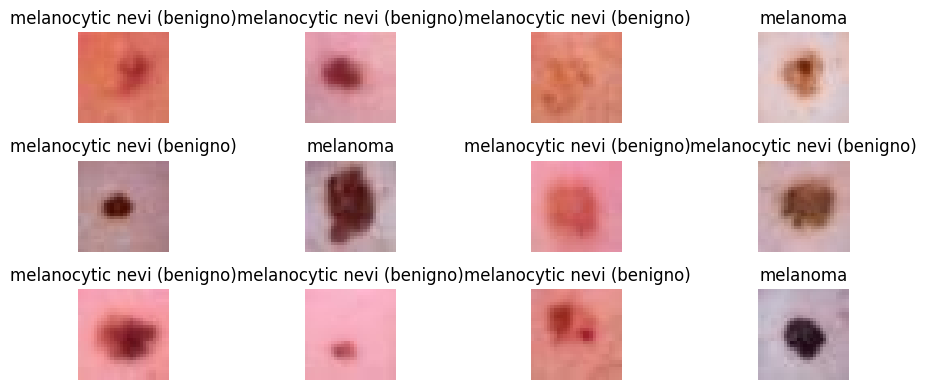

In [49]:
def show_batch(dataset, n=12, class_names=None):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)

        # x tiene forma (3, 28, 28) -> la pasamos a (28, 28, 3) para poder mostrarla a color.
        img = x.permute(1, 2, 0).numpy()
        plt.imshow(img)

        label_idx = int(y.item())
        label_txt = class_names[label_idx] if class_names is not None else str(label_idx)
        plt.title(label_txt)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12, class_names=class_names)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe (recuerda el paso 2.1: si activaste la GPU en Colab, aquí debería seguir apareciendo `cuda`).


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [51]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# El primer valor del shape nos dirá el tamaño del batch, y el segundo, tercero y cuarto
# corresponden a (canales, alto, ancho). Aquí deberíamos ver 3 canales (RGB), no 1.
next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.

**Nota sobre canales de entrada:** en PneumoniaMNIST usábamos `nn.Conv2d(1, 16, ...)` porque las radiografías son en escala de grises (1 canal). Como DermaMNIST es a color, la primera convolución debe recibir **3 canales** de entrada. Para no dejarlo "quemado" en el código, tomamos ese número directamente de `info["n_channels"]`.


In [52]:
import torch.nn as nn
import torch.nn.functional as F

# Como ya filtramos el dataset a 2 clases, fijamos num_classes = 2 manualmente
# (en vez de usar len(info["label"]), que seguiría devolviendo 8).
num_classes = 2
in_channels = info["n_channels"]   # 3 en el caso de DermaMNIST (RGB)

print(f"num_classes = {num_classes} | in_channels = {in_channels}")

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes, in_channels=in_channels).to(device)
model_scratch


num_classes = 2 | in_channels = 3


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Además, para poder graficar la pérdida de **entrenamiento junto con la de validación** (y así detectar sobreajuste, tal como hicimos en los notebooks anteriores con Keras), la función `evaluate` ahora también calcula y devuelve la pérdida (`loss`) sobre el conjunto que se le pase, no solo accuracy y AUC.


In [53]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """
    Evalúa el modelo sobre 'loader'.
    Si se le pasa 'criterion', también calcula la pérdida promedio (val_loss),
    para poder compararla con la pérdida de entrenamiento en las gráficas.
    """
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        if criterion is not None:
            loss = criterion(logits, y)
            losses.append(loss.item())

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    avg_loss = float(np.mean(losses)) if losses else None

    return acc, auc, avg_loss, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos durante 50 épocas para tener una curva más completa y poder observar con más claridad el comportamiento del modelo a lo largo del entrenamiento (incluyendo si empieza a sobreajustar).
En práctica real, además de esto harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.

Guardamos en `history_scratch` tanto la pérdida de entrenamiento (`train_loss`) como la de validación (`val_loss`), además de `val_acc` y `val_auc`, para poder graficar ambas curvas de pérdida juntas más adelante.


In [54]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 50
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_scratch, val_loader, criterion)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.4380 | val_loss=0.3866 | val_acc=0.8581 | val_auc=0.7347
Epoch 02 | train_loss=0.3823 | val_loss=0.3719 | val_acc=0.8581 | val_auc=0.6866
Epoch 03 | train_loss=0.3713 | val_loss=0.3579 | val_acc=0.8581 | val_auc=0.6970
Epoch 04 | train_loss=0.3590 | val_loss=0.3448 | val_acc=0.8581 | val_auc=0.7207
Epoch 05 | train_loss=0.3469 | val_loss=0.3369 | val_acc=0.8581 | val_auc=0.7416
Epoch 06 | train_loss=0.3420 | val_loss=0.3312 | val_acc=0.8581 | val_auc=0.7602
Epoch 07 | train_loss=0.3311 | val_loss=0.3182 | val_acc=0.8581 | val_auc=0.8017
Epoch 08 | train_loss=0.3272 | val_loss=0.3148 | val_acc=0.8581 | val_auc=0.8238
Epoch 09 | train_loss=0.3187 | val_loss=0.3191 | val_acc=0.8581 | val_auc=0.8195
Epoch 10 | train_loss=0.3245 | val_loss=0.3080 | val_acc=0.8581 | val_auc=0.8414
Epoch 11 | train_loss=0.3155 | val_loss=0.3064 | val_acc=0.8581 | val_auc=0.8338
Epoch 12 | train_loss=0.3155 | val_loss=0.3044 | val_acc=0.8593 | val_auc=0.8421
Epoch 13 | train_loss=0.3104

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste. A diferencia de la versión anterior, ahora la gráfica de pérdida incluye **tanto la curva de entrenamiento como la de validación** en el mismo gráfico: si la pérdida de entrenamiento sigue bajando mientras la de validación se estanca o sube, es una señal clara de sobreajuste (el mismo patrón que vimos antes con los modelos de Keras/IMDB).


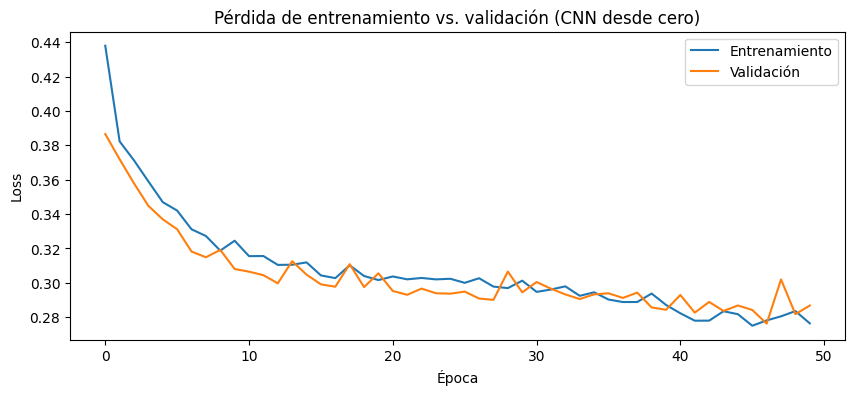

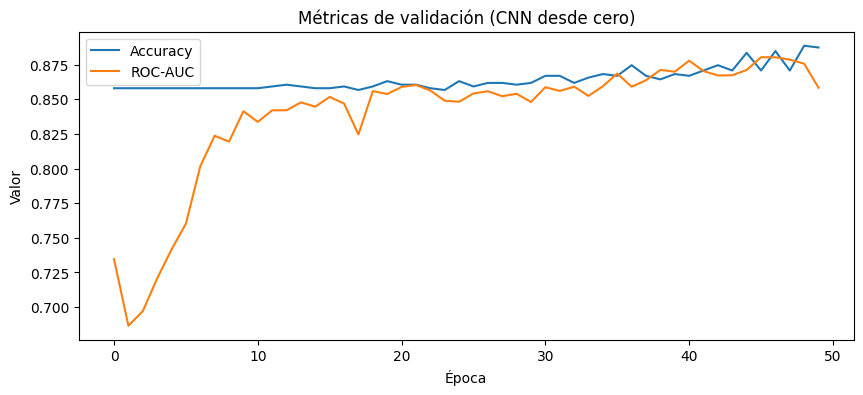

In [55]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Entrenamiento")
plt.plot(history_scratch["val_loss"], label="Validación")
plt.title("Pérdida de entrenamiento vs. validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [56]:
test_acc, test_auc, test_loss, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print(f"Test loss:     {test_loss:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8657
Test ROC-AUC:  0.8709
Test loss:     0.2918

                            precision    recall  f1-score   support

melanocytic nevi (benigno)     0.8793    0.9776    0.9258      1341
                  melanoma     0.5890    0.1928    0.2905       223

                  accuracy                         0.8657      1564
                 macro avg     0.7342    0.5852    0.6082      1564
              weighted avg     0.8379    0.8657    0.8353      1564



array([[1311,   30],
       [ 180,   43]])

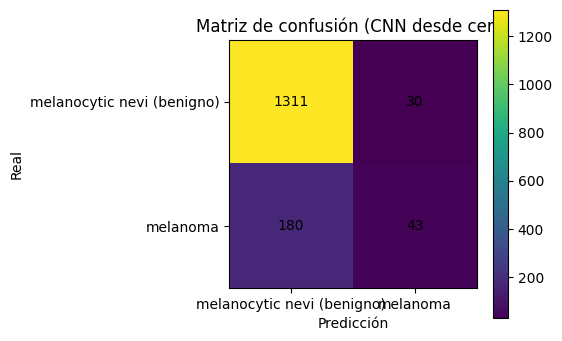

In [57]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Para una lesión de piel fotografiada con dermatoscopio (como en DermaMNIST), volteos horizontales/verticales suelen ser válidos, ya que no existe una "orientación correcta" de la lesión dentro del campo visual (a diferencia de una radiografía de tórax, donde voltear la imagen sí podría ser problemático).

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [58]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

# Igual que antes, aplicamos el aumento sobre el dataset COMPLETO y luego lo filtramos
# a nuestras 2 clases con el mismo wrapper.
train_dataset_aug_full = DataClass(split="train", transform=transform_aug, download=True)
train_dataset_aug = BinaryClassDataset(train_dataset_aug_full, class_map)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [59]:
model_aug = SimpleCNN(num_classes=num_classes, in_channels=in_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 50
history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_aug, val_loader, criterion)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.4451 | val_loss=0.3950 | val_acc=0.8581 | val_auc=0.6673
Epoch 02 | train_loss=0.3913 | val_loss=0.3747 | val_acc=0.8581 | val_auc=0.7155
Epoch 03 | train_loss=0.3670 | val_loss=0.3452 | val_acc=0.8581 | val_auc=0.7121
Epoch 04 | train_loss=0.3495 | val_loss=0.3404 | val_acc=0.8581 | val_auc=0.7450
Epoch 05 | train_loss=0.3385 | val_loss=0.3312 | val_acc=0.8581 | val_auc=0.7588
Epoch 06 | train_loss=0.3332 | val_loss=0.3237 | val_acc=0.8581 | val_auc=0.7708
Epoch 07 | train_loss=0.3297 | val_loss=0.3175 | val_acc=0.8581 | val_auc=0.7996
Epoch 08 | train_loss=0.3304 | val_loss=0.3205 | val_acc=0.8581 | val_auc=0.8211
Epoch 09 | train_loss=0.3214 | val_loss=0.3298 | val_acc=0.8581 | val_auc=0.8332
Epoch 10 | train_loss=0.3254 | val_loss=0.3231 | val_acc=0.8581 | val_auc=0.8196
Epoch 11 | train_loss=0.3151 | val_loss=0.3076 | val_acc=0.8581 | val_auc=0.8372
Epoch 12 | train_loss=0.3135 | val_loss=0.3130 | val_acc=0.8581 | val_auc=0.8283
Epoch 13 | train_loss=0.3080

### 6.1. Comparación rápida

In [60]:
test_acc_aug, test_auc_aug, test_loss_aug, _, _, _ = evaluate(model_aug, test_loader, criterion)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8657 | test_auc=0.8709
Con augmentation  | test_acc=0.8689 | test_auc=0.8781


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises (no es el caso aquí).
- El dominio (microscopía celular) es distinto al de fotos naturales, que es con lo que se entrenó originalmente ImageNet.

**Diferencia importante frente a PneumoniaMNIST:** como esas radiografías eran en 1 canal (escala de grises), había que "triplicar" el canal con `T.Lambda(lambda x: x.repeat(3, 1, 1))` para simular una imagen RGB y así poder usar ResNet18 (que espera 3 canales). **DermaMNIST ya es a color (3 canales)**, así que ese truco ya no es necesario: simplemente redimensionamos la imagen a 224x224.


In [61]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
    # Ya no hace falta T.Lambda(lambda x: x.repeat(3, 1, 1)): DermaMNIST ya tiene 3 canales.
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

train_dataset_tl_full = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl_full = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl_full = DataClass(split="test", transform=transform_tl_eval, download=True)

train_dataset_tl = BinaryClassDataset(train_dataset_tl_full, class_map)
val_dataset_tl = BinaryClassDataset(val_dataset_tl_full, class_map)
test_dataset_tl = BinaryClassDataset(test_dataset_tl_full, class_map)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Debería mostrar (batch, 3, 224, 224) para las imágenes.
next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [62]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [63]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 50
history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.3379 | val_loss=0.2840 | val_acc=0.8836 | val_auc=0.8773
Stage1 Epoch 02 | train_loss=0.2959 | val_loss=0.2863 | val_acc=0.8708 | val_auc=0.8899
Stage1 Epoch 03 | train_loss=0.2900 | val_loss=0.3037 | val_acc=0.8504 | val_auc=0.8922
Stage1 Epoch 04 | train_loss=0.2900 | val_loss=0.3219 | val_acc=0.8312 | val_auc=0.8948
Stage1 Epoch 05 | train_loss=0.2843 | val_loss=0.2581 | val_acc=0.8951 | val_auc=0.8930
Stage1 Epoch 06 | train_loss=0.2723 | val_loss=0.2648 | val_acc=0.8760 | val_auc=0.8969
Stage1 Epoch 07 | train_loss=0.2734 | val_loss=0.2683 | val_acc=0.8747 | val_auc=0.8955
Stage1 Epoch 08 | train_loss=0.2778 | val_loss=0.2575 | val_acc=0.8926 | val_auc=0.8963
Stage1 Epoch 09 | train_loss=0.2696 | val_loss=0.2588 | val_acc=0.8875 | val_auc=0.8964
Stage1 Epoch 10 | train_loss=0.2751 | val_loss=0.2620 | val_acc=0.8836 | val_auc=0.8977
Stage1 Epoch 11 | train_loss=0.2664 | val_loss=0.2562 | val_acc=0.8887 | val_auc=0.8982
Stage1 Epoch 12 | train_loss=0.2

### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [64]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [65]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 50
history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.2821 | val_loss=0.2567 | val_acc=0.8926 | val_auc=0.9113
Stage2 Epoch 02 | train_loss=0.2224 | val_loss=0.2486 | val_acc=0.9079 | val_auc=0.9169
Stage2 Epoch 03 | train_loss=0.1841 | val_loss=0.2758 | val_acc=0.8875 | val_auc=0.9046
Stage2 Epoch 04 | train_loss=0.1660 | val_loss=0.3718 | val_acc=0.8900 | val_auc=0.8962
Stage2 Epoch 05 | train_loss=0.1191 | val_loss=0.3042 | val_acc=0.8964 | val_auc=0.9086
Stage2 Epoch 06 | train_loss=0.1038 | val_loss=0.3207 | val_acc=0.8913 | val_auc=0.9182
Stage2 Epoch 07 | train_loss=0.0772 | val_loss=0.2980 | val_acc=0.8862 | val_auc=0.9152
Stage2 Epoch 08 | train_loss=0.0668 | val_loss=0.3557 | val_acc=0.8951 | val_auc=0.9041
Stage2 Epoch 09 | train_loss=0.0540 | val_loss=0.4063 | val_acc=0.9028 | val_auc=0.9032
Stage2 Epoch 10 | train_loss=0.0443 | val_loss=0.4133 | val_acc=0.8900 | val_auc=0.9076
Stage2 Epoch 11 | train_loss=0.0412 | val_loss=0.5112 | val_acc=0.9041 | val_auc=0.9008
Stage2 Epoch 12 | train_loss=0.0

### 7.2.1. Curva de entrenamiento vs. validación (transfer learning)

Igual que en la CNN desde cero, graficamos la pérdida de entrenamiento junto con la de validación, esta vez uniendo ambas etapas (congelado + fine-tuning) para ver la evolución completa.


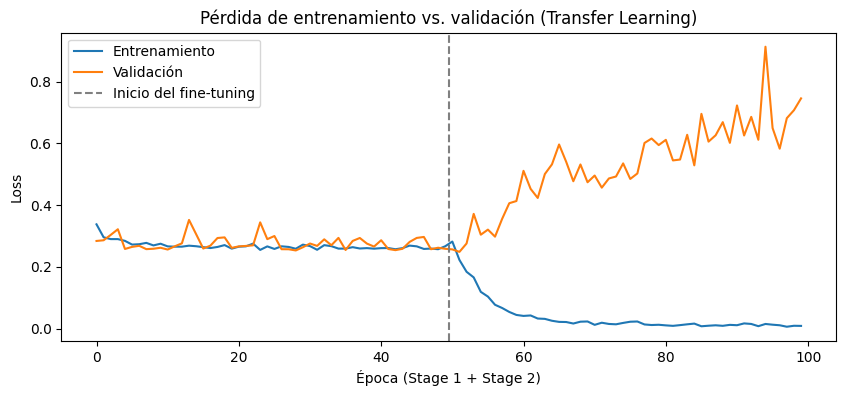

In [66]:
train_loss_tl = history_tl_stage1["train_loss"] + history_tl_stage2["train_loss"]
val_loss_tl = history_tl_stage1["val_loss"] + history_tl_stage2["val_loss"]

plt.figure(figsize=(10, 4))
plt.plot(train_loss_tl, label="Entrenamiento")
plt.plot(val_loss_tl, label="Validación")
plt.axvline(x=len(history_tl_stage1["train_loss"]) - 0.5, color="gray", linestyle="--",
            label="Inicio del fine-tuning")
plt.title("Pérdida de entrenamiento vs. validación (Transfer Learning)")
plt.xlabel("Época (Stage 1 + Stage 2)")
plt.ylabel("Loss")
plt.legend()
plt.show()


### 7.3. Evaluación en test del modelo con transfer learning

In [67]:
test_acc_tl, test_auc_tl, test_loss_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl, criterion)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f} | test_loss={test_loss_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8919 | test_auc=0.9135 | test_loss=0.6866

                            precision    recall  f1-score   support

melanocytic nevi (benigno)     0.9098    0.9702    0.9390      1341
                  melanoma     0.7015    0.4215    0.5266       223

                  accuracy                         0.8919      1564
                 macro avg     0.8056    0.6958    0.7328      1564
              weighted avg     0.8801    0.8919    0.8802      1564



array([[1301,   40],
       [ 129,   94]])

### 7.4. Comparación global (resumen)

In [68]:
print("Resumen de resultados en test (DermaMNIST: melanocytic nevi vs. melanoma)")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test (DermaMNIST: melanocytic nevi vs. melanoma)
CNN desde cero (sin aug)   | acc=0.8657 | auc=0.8709
CNN desde cero (con aug)   | acc=0.8689 | auc=0.8781
Transfer learning (ResNet) | acc=0.8919 | auc=0.9135


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [69]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


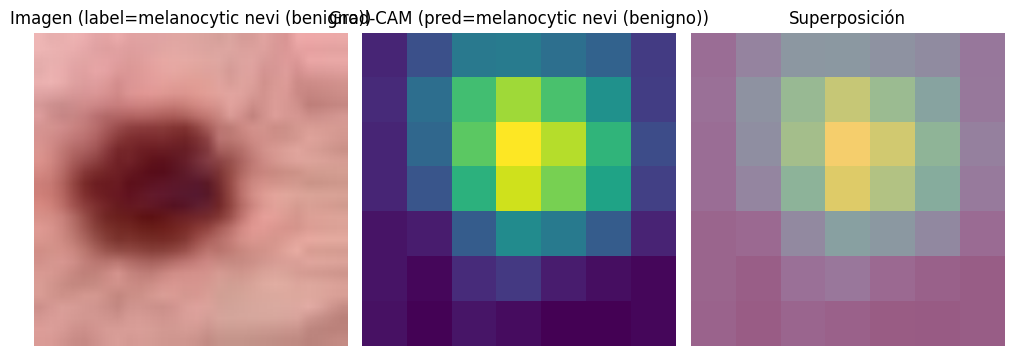

In [70]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

# x tiene forma (3, 224, 224); la pasamos a (224, 224, 3) para mostrarla a color,
# a diferencia de PneumoniaMNIST donde usábamos x[0] con cmap="gray" (1 solo canal).
img = x.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (label={class_names[int(y.item())]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={class_names[pred_class]})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos de cada clase.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global entre clases.

3) Cuidado con sesgos, por ejemplo en el caso de DermaMNIST:
- Diferencias en el equipo de dermatoscopía usado para capturar las imágenes entre distintas clínicas.
- Variabilidad entre tonos de piel: los datasets dermatológicos suelen estar dominados por pieles claras, y un modelo entrenado así puede generalizar peor en pieles más oscuras.
- Variabilidad entre poblaciones de pacientes (edad, tipo de piel, exposición solar, etc.).

4) Al reducir un problema multiclase (7 clases) a binario (2 clases), como hicimos aquí, ten en cuenta que estás **descartando información**: en un caso real, probablemente quieras evaluar si el modelo también podría confundir una de tus 2 clases con alguna de las 5 clases que dejaste fuera (por ejemplo, con una queratosis benigna, que visualmente puede parecerse a un nevo o a un melanoma temprano).


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


### 11 Arquitectura de la CNN: BatchNorm, Dropout y más filtros

Estas son tres de las modificaciones más comunes para mejorar una CNN base:

- **`BatchNorm2d`**: normaliza las activaciones de cada mini-lote después de cada convolución. Esto suele acelerar la convergencia y hacer que el entrenamiento sea menos sensible a la elección del learning rate.
- **`Dropout`**: apaga aleatoriamente una fracción de las neuronas o canales durante el entrenamiento, obligando a la red a no depender demasiado de unas pocas unidades. Es el mismo principio que se vio en los notebooks anteriores de Keras, donde se alternaba `Dense` + `Dropout(0.5)`; aquí se traduce en alternar bloques convolucionales con `Dropout2d`, más un `Dropout` final antes de la capa de clasificación.
- **Más filtros por bloque**: pasar, por ejemplo, de 16/32/64 a 32/64/128 filtros le da a la red más capacidad para representar patrones, aunque también aumenta la cantidad de parámetros y el tiempo de entrenamiento.

La clase `ImprovedCNN` reúne estos tres cambios sobre la arquitectura base (`SimpleCNN`).


In [71]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/dermamnist_cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/dermamnist_cnn_aug.pth")
torch.save(resnet.state_dict(), "models/dermamnist_resnet_transfer.pth")

["models/dermamnist_cnn_scratch.pth", "models/dermamnist_cnn_aug.pth", "models/dermamnist_resnet_transfer.pth"]


['models/dermamnist_cnn_scratch.pth',
 'models/dermamnist_cnn_aug.pth',
 'models/dermamnist_resnet_transfer.pth']

In [72]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),   # dropout leve tras el primer bloque

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),   # un poco más de dropout en el segundo bloque

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),   # dropout más fuerte antes de la capa final, como en Keras
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_improved = ImprovedCNN(num_classes=num_classes, in_channels=in_channels).to(device)
model_improved


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.3, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2

In [73]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_improved.parameters(), lr=1e-3)

epochs = 50
history_improved = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_improved, train_loader, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_improved, val_loader, criterion)

    history_improved["train_loss"].append(train_loss)
    history_improved["val_loss"].append(val_loss)
    history_improved["val_acc"].append(val_acc)
    history_improved["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.4310 | val_loss=0.3220 | val_acc=0.8581 | val_auc=0.8110
Epoch 02 | train_loss=0.3335 | val_loss=0.3053 | val_acc=0.8670 | val_auc=0.8411
Epoch 03 | train_loss=0.3233 | val_loss=0.2991 | val_acc=0.8593 | val_auc=0.8448
Epoch 04 | train_loss=0.3175 | val_loss=0.2988 | val_acc=0.8657 | val_auc=0.8561
Epoch 05 | train_loss=0.3121 | val_loss=0.2997 | val_acc=0.8632 | val_auc=0.8531
Epoch 06 | train_loss=0.3108 | val_loss=0.2924 | val_acc=0.8683 | val_auc=0.8590
Epoch 07 | train_loss=0.3095 | val_loss=0.3245 | val_acc=0.8606 | val_auc=0.8391
Epoch 08 | train_loss=0.3073 | val_loss=0.2897 | val_acc=0.8683 | val_auc=0.8676
Epoch 09 | train_loss=0.3010 | val_loss=0.2870 | val_acc=0.8696 | val_auc=0.8578
Epoch 10 | train_loss=0.3031 | val_loss=0.3223 | val_acc=0.8696 | val_auc=0.8728
Epoch 11 | train_loss=0.2989 | val_loss=0.3047 | val_acc=0.8619 | val_auc=0.8634
Epoch 12 | train_loss=0.3004 | val_loss=0.2897 | val_acc=0.8721 | val_auc=0.8571
Epoch 13 | train_loss=0.2970

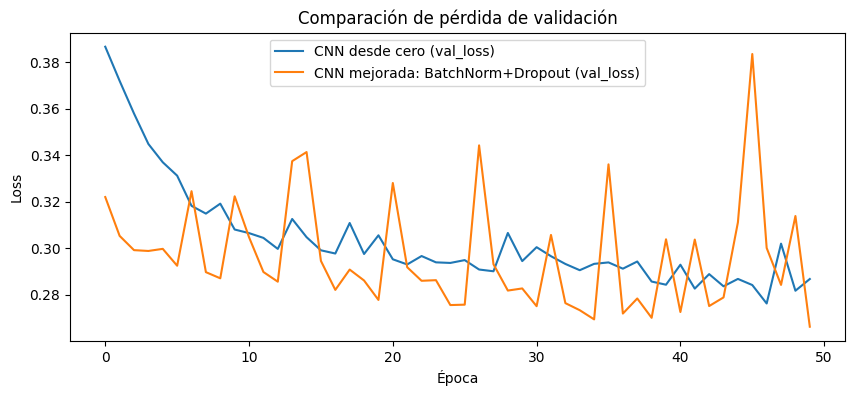

CNN desde cero              | test_acc=0.8657 | test_auc=0.8709
CNN mejorada (BN + Dropout) | test_acc=0.8849 | test_auc=0.8973


In [74]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_loss"], label="CNN desde cero (val_loss)")
plt.plot(history_improved["val_loss"], label="CNN mejorada: BatchNorm+Dropout (val_loss)")
plt.title("Comparación de pérdida de validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_acc_improved, test_auc_improved, test_loss_improved, _, _, _ = evaluate(model_improved, test_loader, criterion)
print(f"CNN desde cero              | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"CNN mejorada (BN + Dropout) | test_acc={test_acc_improved:.4f} | test_auc={test_auc_improved:.4f}")


### 11.2. Learning rate y scheduler

El *learning rate* controla qué tan grandes son los ajustes que el optimizador aplica a los pesos en cada paso. Mantenerlo fijo durante todo el entrenamiento no siempre es lo ideal: un valor más alto ayuda a avanzar rápido al principio, pero hacia el final puede hacer que los pesos oscilen en vez de asentarse en un buen mínimo.

Un **scheduler** ajusta el learning rate automáticamente durante el entrenamiento. `ReduceLROnPlateau`, en particular, reduce el learning rate cuando una métrica de referencia (aquí, la pérdida de validación) deja de mejorar durante un número determinado de épocas (`patience`), lo que suele ayudar a que el modelo termine de afinarse en las últimas épocas.


In [75]:
model_lr = ImprovedCNN(num_classes=num_classes, in_channels=in_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lr.parameters(), lr=1e-3)

# El scheduler observa 'val_loss': si no mejora durante 'patience' épocas seguidas,
# multiplica el learning rate por 'factor' (lo reduce a la mitad).
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

epochs = 50
history_lr = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_lr, train_loader, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_lr, val_loader, criterion)

    # El scheduler decide si baja el learning rate en base a la pérdida de validación.
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history_lr["train_loss"].append(train_loss)
    history_lr["val_loss"].append(val_loss)
    history_lr["val_acc"].append(val_acc)
    history_lr["val_auc"].append(val_auc)
    history_lr["lr"].append(current_lr)

    print(f"Epoch {epoch:02d} | lr={current_lr:.6f} | train_loss={train_loss:.4f} "
          f"| val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | lr=0.001000 | train_loss=0.3939 | val_loss=0.3329 | val_acc=0.8581 | val_auc=0.7850
Epoch 02 | lr=0.001000 | train_loss=0.3285 | val_loss=0.3010 | val_acc=0.8645 | val_auc=0.8410
Epoch 03 | lr=0.001000 | train_loss=0.3174 | val_loss=0.3130 | val_acc=0.8593 | val_auc=0.8318
Epoch 04 | lr=0.001000 | train_loss=0.3142 | val_loss=0.3030 | val_acc=0.8619 | val_auc=0.8600
Epoch 05 | lr=0.001000 | train_loss=0.3110 | val_loss=0.2936 | val_acc=0.8683 | val_auc=0.8528
Epoch 06 | lr=0.001000 | train_loss=0.3110 | val_loss=0.3001 | val_acc=0.8657 | val_auc=0.8664
Epoch 07 | lr=0.001000 | train_loss=0.3061 | val_loss=0.3335 | val_acc=0.8542 | val_auc=0.7950
Epoch 08 | lr=0.000500 | train_loss=0.3037 | val_loss=0.3288 | val_acc=0.8593 | val_auc=0.8358
Epoch 09 | lr=0.000500 | train_loss=0.3011 | val_loss=0.2931 | val_acc=0.8632 | val_auc=0.8639
Epoch 10 | lr=0.000500 | train_loss=0.2955 | val_loss=0.2847 | val_acc=0.8645 | val_auc=0.8750
Epoch 11 | lr=0.000500 | train_loss=0.3005 | val_l

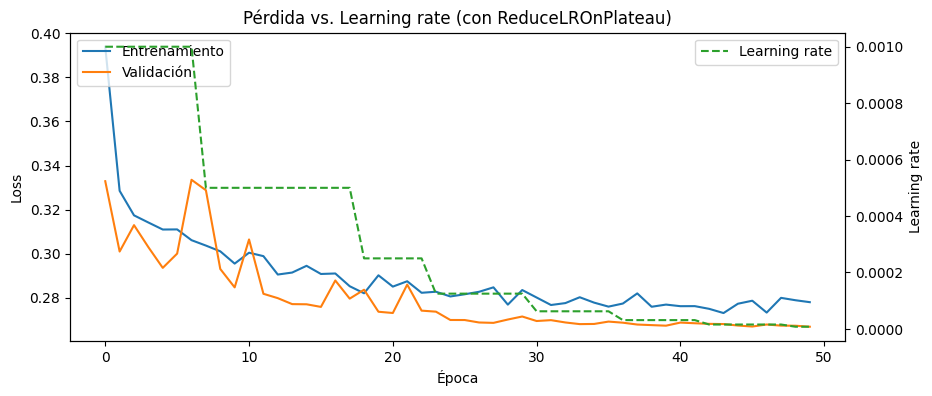

CNN mejorada + scheduler | test_acc=0.8830 | test_auc=0.8949


In [82]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(history_lr["train_loss"], label="Entrenamiento", color="tab:blue")
ax1.plot(history_lr["val_loss"], label="Validación", color="tab:orange")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper left")

# Eje secundario para ver cómo baja el learning rate con el scheduler.
ax2 = ax1.twinx()
ax2.plot(history_lr["lr"], label="Learning rate", color="tab:green", linestyle="--")
ax2.set_ylabel("Learning rate")
ax2.legend(loc="upper right")

plt.title("Pérdida vs. Learning rate (con ReduceLROnPlateau)")
plt.show()

test_acc_lr, test_auc_lr, test_loss_lr, _, _, _ = evaluate(model_lr, test_loader, criterion)
print(f"CNN mejorada + scheduler | test_acc={test_acc_lr:.4f} | test_auc={test_auc_lr:.4f}")


### 11.3. Impacto de distintos aumentos de datos

El aumento "moderado" usado en la sección 6 (rotación ± 10° y traslación leve) es solo un punto dentro de un rango mucho más amplio de transformaciones posibles. Aumentos más agresivos —como el volteo horizontal, el volteo vertical o variaciones de brillo/contraste (`ColorJitter`)— pueden aportar más o menos según el tipo de imagen: para una lesión de piel fotografiada con dermatoscopio, como en DermaMNIST, voltear la imagen no cambia su interpretación clínica (no hay una "orientación correcta"), a diferencia de, por ejemplo, una radiografía de tórax, donde ciertas transformaciones sí podrían ser problemáticas. El brillo y el contraste, en cambio, hay que variarlos con cuidado: un cambio muy fuerte podría borrar justamente la variación de color que es clave para distinguir un nevo de un melanoma.


In [77]:
transform_aug_v2 = T.Compose([
    T.RandomRotation(degrees=20),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor()
])

train_dataset_aug_v2_full = DataClass(split="train", transform=transform_aug_v2, download=True)
train_dataset_aug_v2 = BinaryClassDataset(train_dataset_aug_v2_full, class_map)
train_loader_aug_v2 = DataLoader(train_dataset_aug_v2, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

model_aug_v2 = SimpleCNN(num_classes=num_classes, in_channels=in_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug_v2.parameters(), lr=1e-3)

epochs = 50
history_aug_v2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug_v2, train_loader_aug_v2, optimizer, criterion)
    val_acc, val_auc, val_loss, _, _, _ = evaluate(model_aug_v2, val_loader, criterion)

    history_aug_v2["train_loss"].append(train_loss)
    history_aug_v2["val_loss"].append(val_loss)
    history_aug_v2["val_acc"].append(val_acc)
    history_aug_v2["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.4541 | val_loss=0.4013 | val_acc=0.8581 | val_auc=0.7075
Epoch 02 | train_loss=0.3942 | val_loss=0.3812 | val_acc=0.8581 | val_auc=0.6869
Epoch 03 | train_loss=0.3856 | val_loss=0.3727 | val_acc=0.8581 | val_auc=0.6700
Epoch 04 | train_loss=0.3806 | val_loss=0.3812 | val_acc=0.8581 | val_auc=0.6832
Epoch 05 | train_loss=0.3726 | val_loss=0.3576 | val_acc=0.8581 | val_auc=0.7024
Epoch 06 | train_loss=0.3703 | val_loss=0.3569 | val_acc=0.8581 | val_auc=0.7209
Epoch 07 | train_loss=0.3729 | val_loss=0.3490 | val_acc=0.8581 | val_auc=0.7199
Epoch 08 | train_loss=0.3641 | val_loss=0.3449 | val_acc=0.8581 | val_auc=0.7341
Epoch 09 | train_loss=0.3578 | val_loss=0.3543 | val_acc=0.8581 | val_auc=0.7284
Epoch 10 | train_loss=0.3574 | val_loss=0.3472 | val_acc=0.8581 | val_auc=0.7360
Epoch 11 | train_loss=0.3572 | val_loss=0.3606 | val_acc=0.8581 | val_auc=0.7411
Epoch 12 | train_loss=0.3504 | val_loss=0.3229 | val_acc=0.8581 | val_auc=0.7858
Epoch 13 | train_loss=0.3517

In [78]:
test_acc_aug_v2, test_auc_aug_v2, test_loss_aug_v2, _, _, _ = evaluate(model_aug_v2, test_loader, criterion)

print("Comparación del efecto de distintos aumentos de datos")
print(f"Sin augmentation                     | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Augmentation moderado (rotación+trasl.) | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")
print(f"Augmentation agresivo (+flip+color)     | test_acc={test_acc_aug_v2:.4f} | test_auc={test_auc_aug_v2:.4f}")


Comparación del efecto de distintos aumentos de datos
Sin augmentation                     | test_acc=0.8657 | test_auc=0.8709
Augmentation moderado (rotación+trasl.) | test_acc=0.8689 | test_auc=0.8781
Augmentation agresivo (+flip+color)     | test_acc=0.8587 | test_auc=0.8622


### 11.4. Cambiar el dataset dentro de `medmnist`

`medmnist` agrupa varios datasets médicos bajo una misma interfaz (`INFO`, `DataClass`, particiones de train/val/test ya definidas), lo que en principio permite pasar de un dataset a otro sin reescribir todo el pipeline. Sin embargo, cada dataset tiene particularidades propias que conviene revisar antes de reutilizar el código:

- **Número de canales** (`info["n_channels"]`): algunos datasets son en escala de grises (1 canal, como PneumoniaMNIST) y otros a color (3 canales, como BloodMNIST o DermaMNIST). Esto afecta directamente la primera capa convolucional y las transformaciones usadas para transfer learning.
- **Número de clases** (`info["label"]`): algunos datasets ya son binarios (como `breastmnist`), mientras que otros tienen varias clases (como `bloodmnist`, con 8, o `dermamnist`, con 7), lo que puede requerir agrupar o seleccionar categorías si se quiere plantear un problema binario.
- **Forma de visualizar las imágenes**: por ejemplo, usar `cmap="gray"` solo tiene sentido cuando la imagen tiene 1 canal; con imágenes a color hay que reordenar los ejes del tensor para mostrarlas correctamente.

Estos son, en general, los puntos que hay que revisar al migrar este tipo de pipeline entre distintos datasets de `medmnist`, como `pneumoniamnist`, `bloodmnist`, `breastmnist` o `dermamnist`.


### 11.5. Calibración de probabilidades y curvas ROC

Un modelo puede tener buena accuracy y, aun así, sus probabilidades pueden estar "mal calibradas": por ejemplo, asignar 90% de confianza a predicciones que en realidad aciertan solo el 70% de las veces. Dos herramientas ayudan a analizar esto:

- **Curva de calibración**: compara la probabilidad predicha por el modelo contra la frecuencia real de aciertos, agrupando las predicciones en bloques (bins). Mientras más cerca esté de la diagonal, mejor calibrado está el modelo.
- **Curva ROC**: muestra el balance entre sensibilidad (recall) y tasa de falsos positivos para distintos umbrales de decisión; el área bajo la curva (ROC-AUC) resume ese balance en un solo número.

Las celdas siguientes calculan ambas métricas sobre las predicciones del modelo con transfer learning (`resnet`) en el conjunto de test.


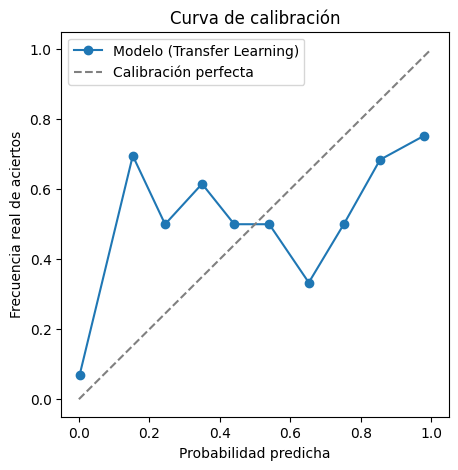

Brier score (más cercano a 0 es mejor): 0.0945


In [79]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc, brier_score_loss

# y_prob_tl y y_true_tl ya los calculamos en la sección 7.3 al evaluar el modelo de transfer learning.
prob_true, prob_pred = calibration_curve(y_true_tl, y_prob_tl, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo (Transfer Learning)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia real de aciertos")
plt.title("Curva de calibración")
plt.legend()
plt.show()

brier = brier_score_loss(y_true_tl, y_prob_tl)
print(f"Brier score (más cercano a 0 es mejor): {brier:.4f}")


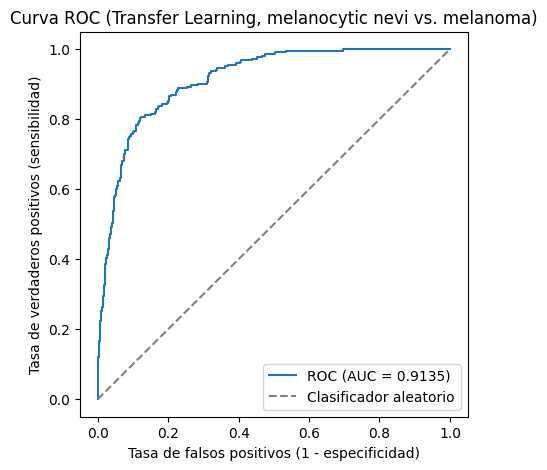

In [80]:
fpr, tpr, thresholds = roc_curve(y_true_tl, y_prob_tl)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC (Transfer Learning, melanocytic nevi vs. melanoma)")
plt.legend()
plt.show()


## Conclusión

Este notebook trasladó el flujo de trabajo usado con PneumoniaMNIST hacia **DermaMNIST**, reduciendo un problema de 7 clases a uno binario (`melanocytic nevi` vs. `melanoma`), y profundizó en varios temas relevantes para mejorar y entender un modelo de clasificación de imágenes: arquitecturas con BatchNorm y Dropout, ajuste del learning rate mediante schedulers, el efecto de distintos niveles de aumento de datos, las consideraciones al cambiar de dataset dentro de `medmnist`, y el análisis de calibración de probabilidades junto con la curva ROC del modelo con mejor desempeño (transfer learning con ResNet18).
